In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
import json
warnings.filterwarnings('ignore')

## DF to 3D Array

In [2]:

def positional_encoding(position, d_model):
    angle_rates = 1 / np.power(10000, (2 * (np.arange(d_model) // 2)) / np.float32(d_model))
    angle_rads = position * angle_rates

    # apply sin to even indices in the array; 2i
    angle_rads[0::2] = np.sin(angle_rads[0::2])

    # apply cos to odd indices in the array; 2i+1
    angle_rads[1::2] = np.cos(angle_rads[1::2])
    
    return angle_rads[:d_model]

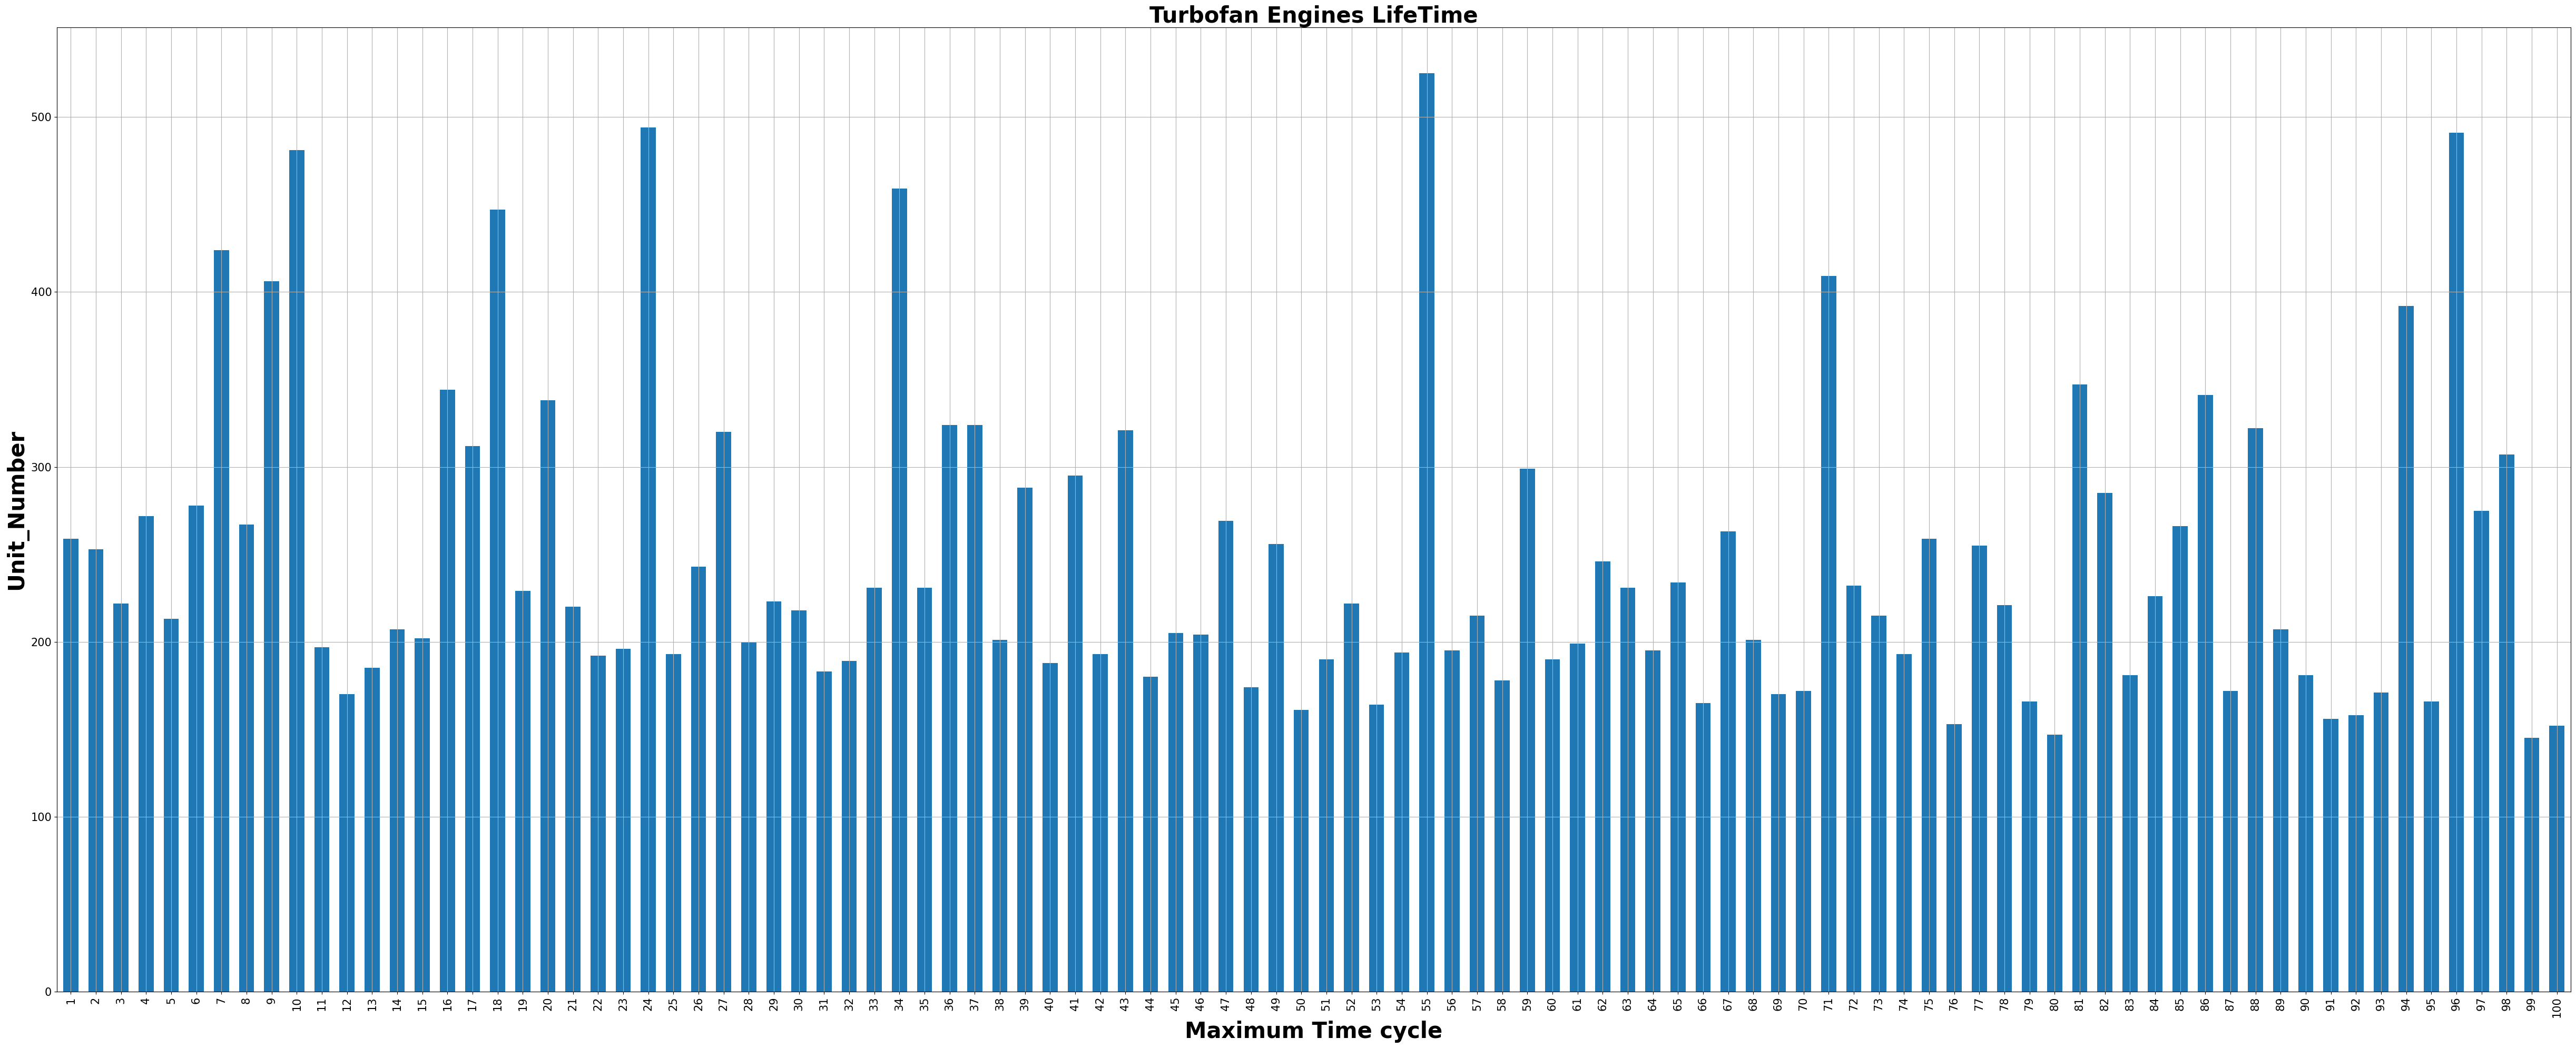

In [3]:
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i+1) for i in range(0,21)]
col_names = index_names + setting_names + sensor_names
filenum = 3
CurrentFile = f"train_FD00{filenum}"
df = pd.read_csv('CMaps/'+ CurrentFile + '.txt',sep='\s+',header=None,index_col=False,names=col_names)
# df.iloc[-1]
# df.head()
max_time_cycles=df[index_names].groupby('unit_number').max()
max_time_cycles.head()
plt.figure(figsize=(49,20))
ax=max_time_cycles['time_cycles'].plot(kind='bar',width=0.6, stacked=True,align='center')
plt.title('Turbofan Engines LifeTime',fontweight='bold',size=30)
plt.xlabel('Maximum Time cycle',fontweight='bold',size=30)
plt.xticks(size=15)
plt.ylabel('Unit_Number',fontweight='bold',size=30)
plt.yticks(size=15)
plt.grid(True)
plt.tight_layout()
plt.savefig('Turbofan_Engines_LifeTime.png')
plt.show()


In [4]:
df.to_csv(CurrentFile+".csv", index=False)
df.head()

,unit_number,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0005,0.0004,100.0,518.67,642.36,1583.23,1396.84,14.62,...,522.31,2388.01,8145.32,8.4246,0.03,391,2388,100.0,39.11,23.3537
1,1,2,0.0008,-0.0003,100.0,518.67,642.50,1584.69,1396.89,14.62,...,522.42,2388.03,8152.85,8.4403,0.03,392,2388,100.0,38.99,23.4491
2,1,3,-0.0014,-0.0002,100.0,518.67,642.18,1582.35,1405.61,14.62,...,522.03,2388.00,8150.17,8.3901,0.03,391,2388,100.0,38.85,23.3669
3,1,4,-0.0020,0.0001,100.0,518.67,642.92,1585.61,1392.27,14.62,...,522.49,2388.08,8146.56,8.3878,0.03,392,2388,100.0,38.96,23.2951
4,1,5,0.0016,0.0000,100.0,518.67,641.68,1588.63,1397.65,14.62,...,522.58,2388.03,8147.80,8.3869,0.03,392,2388,100.0,39.14,23.4583


## Converting All Data

In [ ]:
def VecNorm(UnNormArr):
    #Column wise normalization of each time series sample
    NormArr = UnNormArr
    for i in range(len(UnNormArr)):
        for j in range(len(UnNormArr[i][0])):
            # print([UnNormArr[i][k][j] for k in range(len(UnNormArr[i]))], "\n")
            NormFac = sum([UnNormArr[i][k][j] ** 2 for k in range(len(UnNormArr[i]))])**0.5
            # print(NormFac)
            NormCol = [UnNormArr[i][k][j]/NormFac for k in range(len(UnNormArr[i]))]
            # print(NormCol)
            # print(i,j,len(NormCol), len(NormArr[i]))
            # NormArr[i][:][j] = NormCol

            for k in range(len(UnNormArr[i])):
                NormArr[i][k][j] = NormCol[k]
            # print(NormArr[i][:][j])
            # print([NormArr[i][k][j] for k in range(len(NormArr[i]))], "\n")
            # print(f"Done W row {i} col {j}")
    return NormArr

def normalize_dataframe(df, columns_to_normalize):
    """
    Normalize specified columns of a DataFrame column-wise.

    Parameters:
    df (pd.DataFrame): The DataFrame to normalize.
    columns_to_normalize (list): List of column names to normalize.

    Returns:
    pd.DataFrame: A DataFrame with normalized columns.
    """
    drop = []
    mins = []
    maxes = []
    for column in columns_to_normalize:
        mins.append(df[column].min())
        maxes.append(df[column].max())
        
        print(f"{column} min: {df[column].min()}, max: {df[column].max()}")
        if df[column].min() == df[column].max():
            drop.append(column)
        df[column] = (df[column] - df[column].min()) / (df[column].max() - df[column].min())  # add small epsilon to prevent division by zero
        
    df = df.drop(columns=drop)
    print(f"Dropped: {len(drop)} columns \n {drop}")
    print(f"\n Mins = {mins}")
    print(f"\n Maxes = {maxes}")

    return df
import numpy as np

def all_up(data, n_start=5, n_end=10):
    result = []
    
    for unit in data:
        if len(unit) == 0:
            result.append([])
            continue
            
        # Convert to numpy for easier manipulation
        unit_array = np.array(unit)
        seq_len, n_features = unit_array.shape
        unit_result = unit_array.copy()
        
        for f in range(n_features):
            # Calculate start and end averages
            n_start_actual = min(n_start, seq_len)
            n_end_actual = min(n_end, seq_len)
            
            start_avg = np.mean(unit_array[:n_start_actual, f])
            end_avg = np.mean(unit_array[-n_end_actual:, f])
            
            # If signal is decreasing (end < start), flip it around its start value
            if end_avg < start_avg:
                # Mirror formula: 2*start - x
                unit_result[:, f] = 2 * start_avg - unit_array[:, f]
        
        # Convert back to list
        result.append(unit_result.tolist())
    
    return result

In [6]:
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i+1) for i in range(0,21)]
col_names = index_names + setting_names + sensor_names
for filenum in range(1,2):
    print(f"{filenum}\n\n")
    CurrentFile = f"train_FD00{filenum}"
    df = pd.read_csv('CMaps/'+ CurrentFile + '.txt',sep='\s+',header=None,index_col=False,names=col_names)
    df.drop(columns=['setting_1', 'setting_2', 'setting_3'], inplace=True)
    # print(df.iloc[0,:])
    df = normalize_dataframe(df, sensor_names)
    # print(df.iloc[0,:])
    # break
    Data = [[] for _ in range(df.iloc[-1,0])]
    for i in range(len(df)):
        row = df.iloc[i,2:]
        idx = int(df.iloc[i,0] - 1)
        Data[idx].append(row.tolist())

    dmodel = 24
    # data_pos = Data
    # Data
    # data_pos = Data
    # print(len(data_pos), len(data_pos[0]),len(data_pos[0][0]))
    # for i in range(len(Data)):
    #     posenc1 = positional_encoding(i,dmodel)
    #     posenc1 = posenc1.tolist()
    #     for j in range(len(Data[i])):
    #         posenc2 = positional_encoding(j,dmodel)
    #         posenc2 = posenc2.tolist()
    #         for k in range(len(posenc1)):
    #             data_pos[i][j][k] += posenc1[k] + posenc2[k]
    Data_allup, flipped = all_up(Data)
    with open( 'Data/' + CurrentFile + 'in.json', 'w') as file:
        json.dump(Data_allup, file)
    file.close()
    # with open(CurrentFile + 'NonNormout.json', 'w') as file:
    #     json.dump(data_pos, file)
    # file.close()
    

1


s_1 min: 518.67, max: 518.67
s_2 min: 641.21, max: 644.53
s_3 min: 1571.04, max: 1616.91
s_4 min: 1382.25, max: 1441.49
s_5 min: 14.62, max: 14.62
s_6 min: 21.6, max: 21.61
s_7 min: 549.85, max: 556.06
s_8 min: 2387.9, max: 2388.56
s_9 min: 9021.73, max: 9244.59
s_10 min: 1.3, max: 1.3
s_11 min: 46.85, max: 48.53
s_12 min: 518.69, max: 523.38
s_13 min: 2387.88, max: 2388.56
s_14 min: 8099.94, max: 8293.72
s_15 min: 8.3249, max: 8.5848
s_16 min: 0.03, max: 0.03
s_17 min: 388, max: 400
s_18 min: 2388, max: 2388
s_19 min: 100.0, max: 100.0
s_20 min: 38.14, max: 39.43
s_21 min: 22.8942, max: 23.6184
Dropped: 6 columns 
 ['s_1', 's_5', 's_10', 's_16', 's_18', 's_19']

 Mins = [np.float64(518.67), np.float64(641.21), np.float64(1571.04), np.float64(1382.25), np.float64(14.62), np.float64(21.6), np.float64(549.85), np.float64(2387.9), np.float64(9021.73), np.float64(1.3), np.float64(46.85), np.float64(518.69), np.float64(2387.88), np.float64(8099.94), np.float64(8.3249), np.float64(0.03),

In [7]:
print(flipped)

{0: [4, 6, 8, 10, 13, 14], 1: [4, 8, 13, 14], 2: [4, 8, 13, 14], 3: [4, 8, 13, 14], 4: [4, 8, 13, 14], 5: [4, 6, 8, 10, 13, 14], 6: [4, 8, 10, 13, 14], 7: [3, 4, 8, 10, 13, 14], 8: [4, 8, 13, 14], 9: [4, 8, 13, 14], 10: [4, 8, 13, 14], 11: [3, 4, 8, 10, 13, 14], 12: [4, 8, 13, 14], 13: [4, 8, 13, 14], 14: [4, 6, 8, 10, 13, 14], 15: [3, 4, 8, 10, 13, 14], 16: [4, 8, 13, 14], 17: [4, 8, 13, 14], 18: [3, 4, 6, 8, 10, 13, 14], 19: [3, 4, 8, 13, 14], 20: [3, 4, 8, 13, 14], 21: [4, 8, 13, 14], 22: [4, 8, 10, 13, 14], 23: [4, 6, 8, 10, 13, 14], 24: [3, 4, 8, 13, 14], 25: [3, 4, 8, 13, 14], 26: [4, 8, 13, 14], 27: [4, 8, 13, 14], 28: [4, 6, 8, 10, 13, 14], 29: [4, 6, 8, 10, 13, 14], 30: [4, 6, 8, 10, 13, 14], 31: [4, 8, 13, 14], 32: [4, 6, 8, 10, 13, 14], 33: [4, 8, 13, 14], 34: [4, 8, 13, 14], 35: [3, 4, 6, 8, 10, 13, 14], 36: [3, 4, 6, 8, 10, 13, 14], 37: [4, 8, 13, 14], 38: [4, 6, 8, 10, 13, 14], 39: [4, 8, 13, 14], 40: [4, 8, 13, 14], 41: [4, 8, 10, 13, 14], 42: [4, 6, 8, 10, 13, 14], 43: 

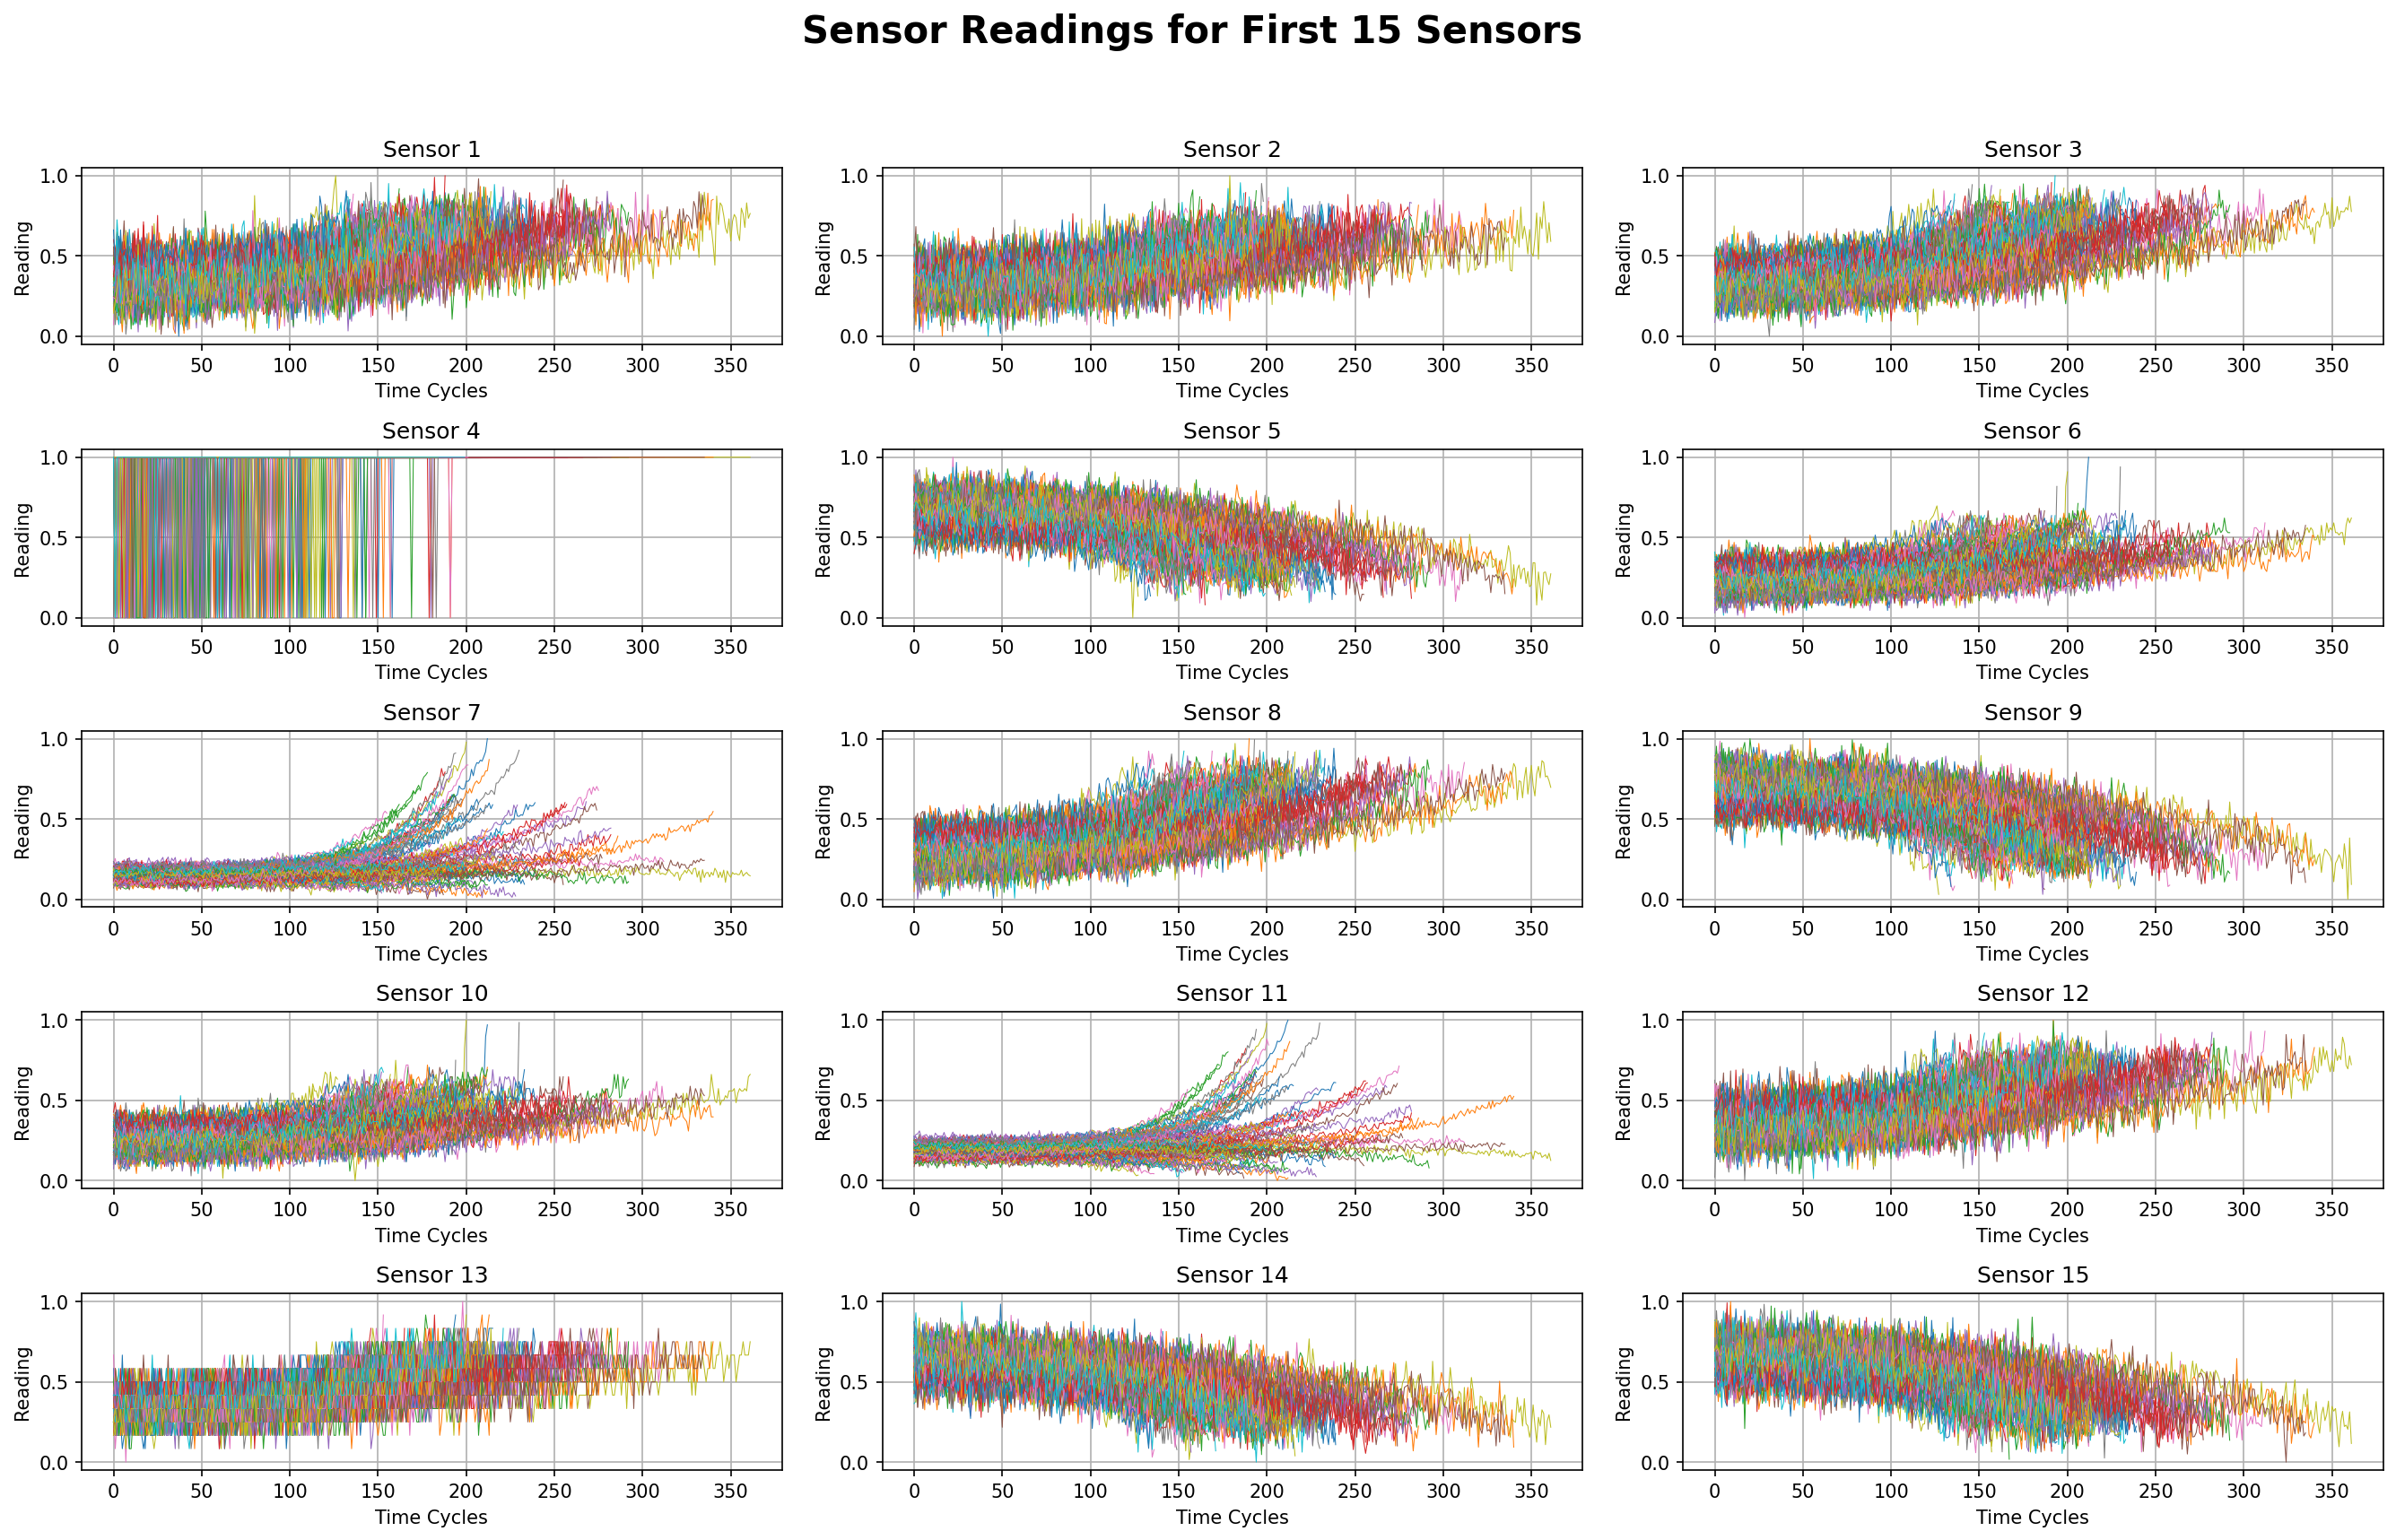

In [8]:
# Data_allup, flipped = all_up(Data)
fig, axs = plt.subplots(5, 3, figsize=(18, 12), dpi=150)
fig.suptitle('Sensor Readings for First 15 Sensors', fontsize=20, fontweight='bold')

n_sensors_to_plot = 15
for idx in range(n_sensors_to_plot):
    ax = axs[idx // 3, idx % 3]
    for engine in Data:
        signal = [flight[idx] for flight in engine]
        ax.plot(signal, linewidth=0.5)
    ax.set_title(f'Sensor {idx+1}')
    ax.set_xlabel('Time Cycles')
    ax.set_ylabel('Reading')
    ax.grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

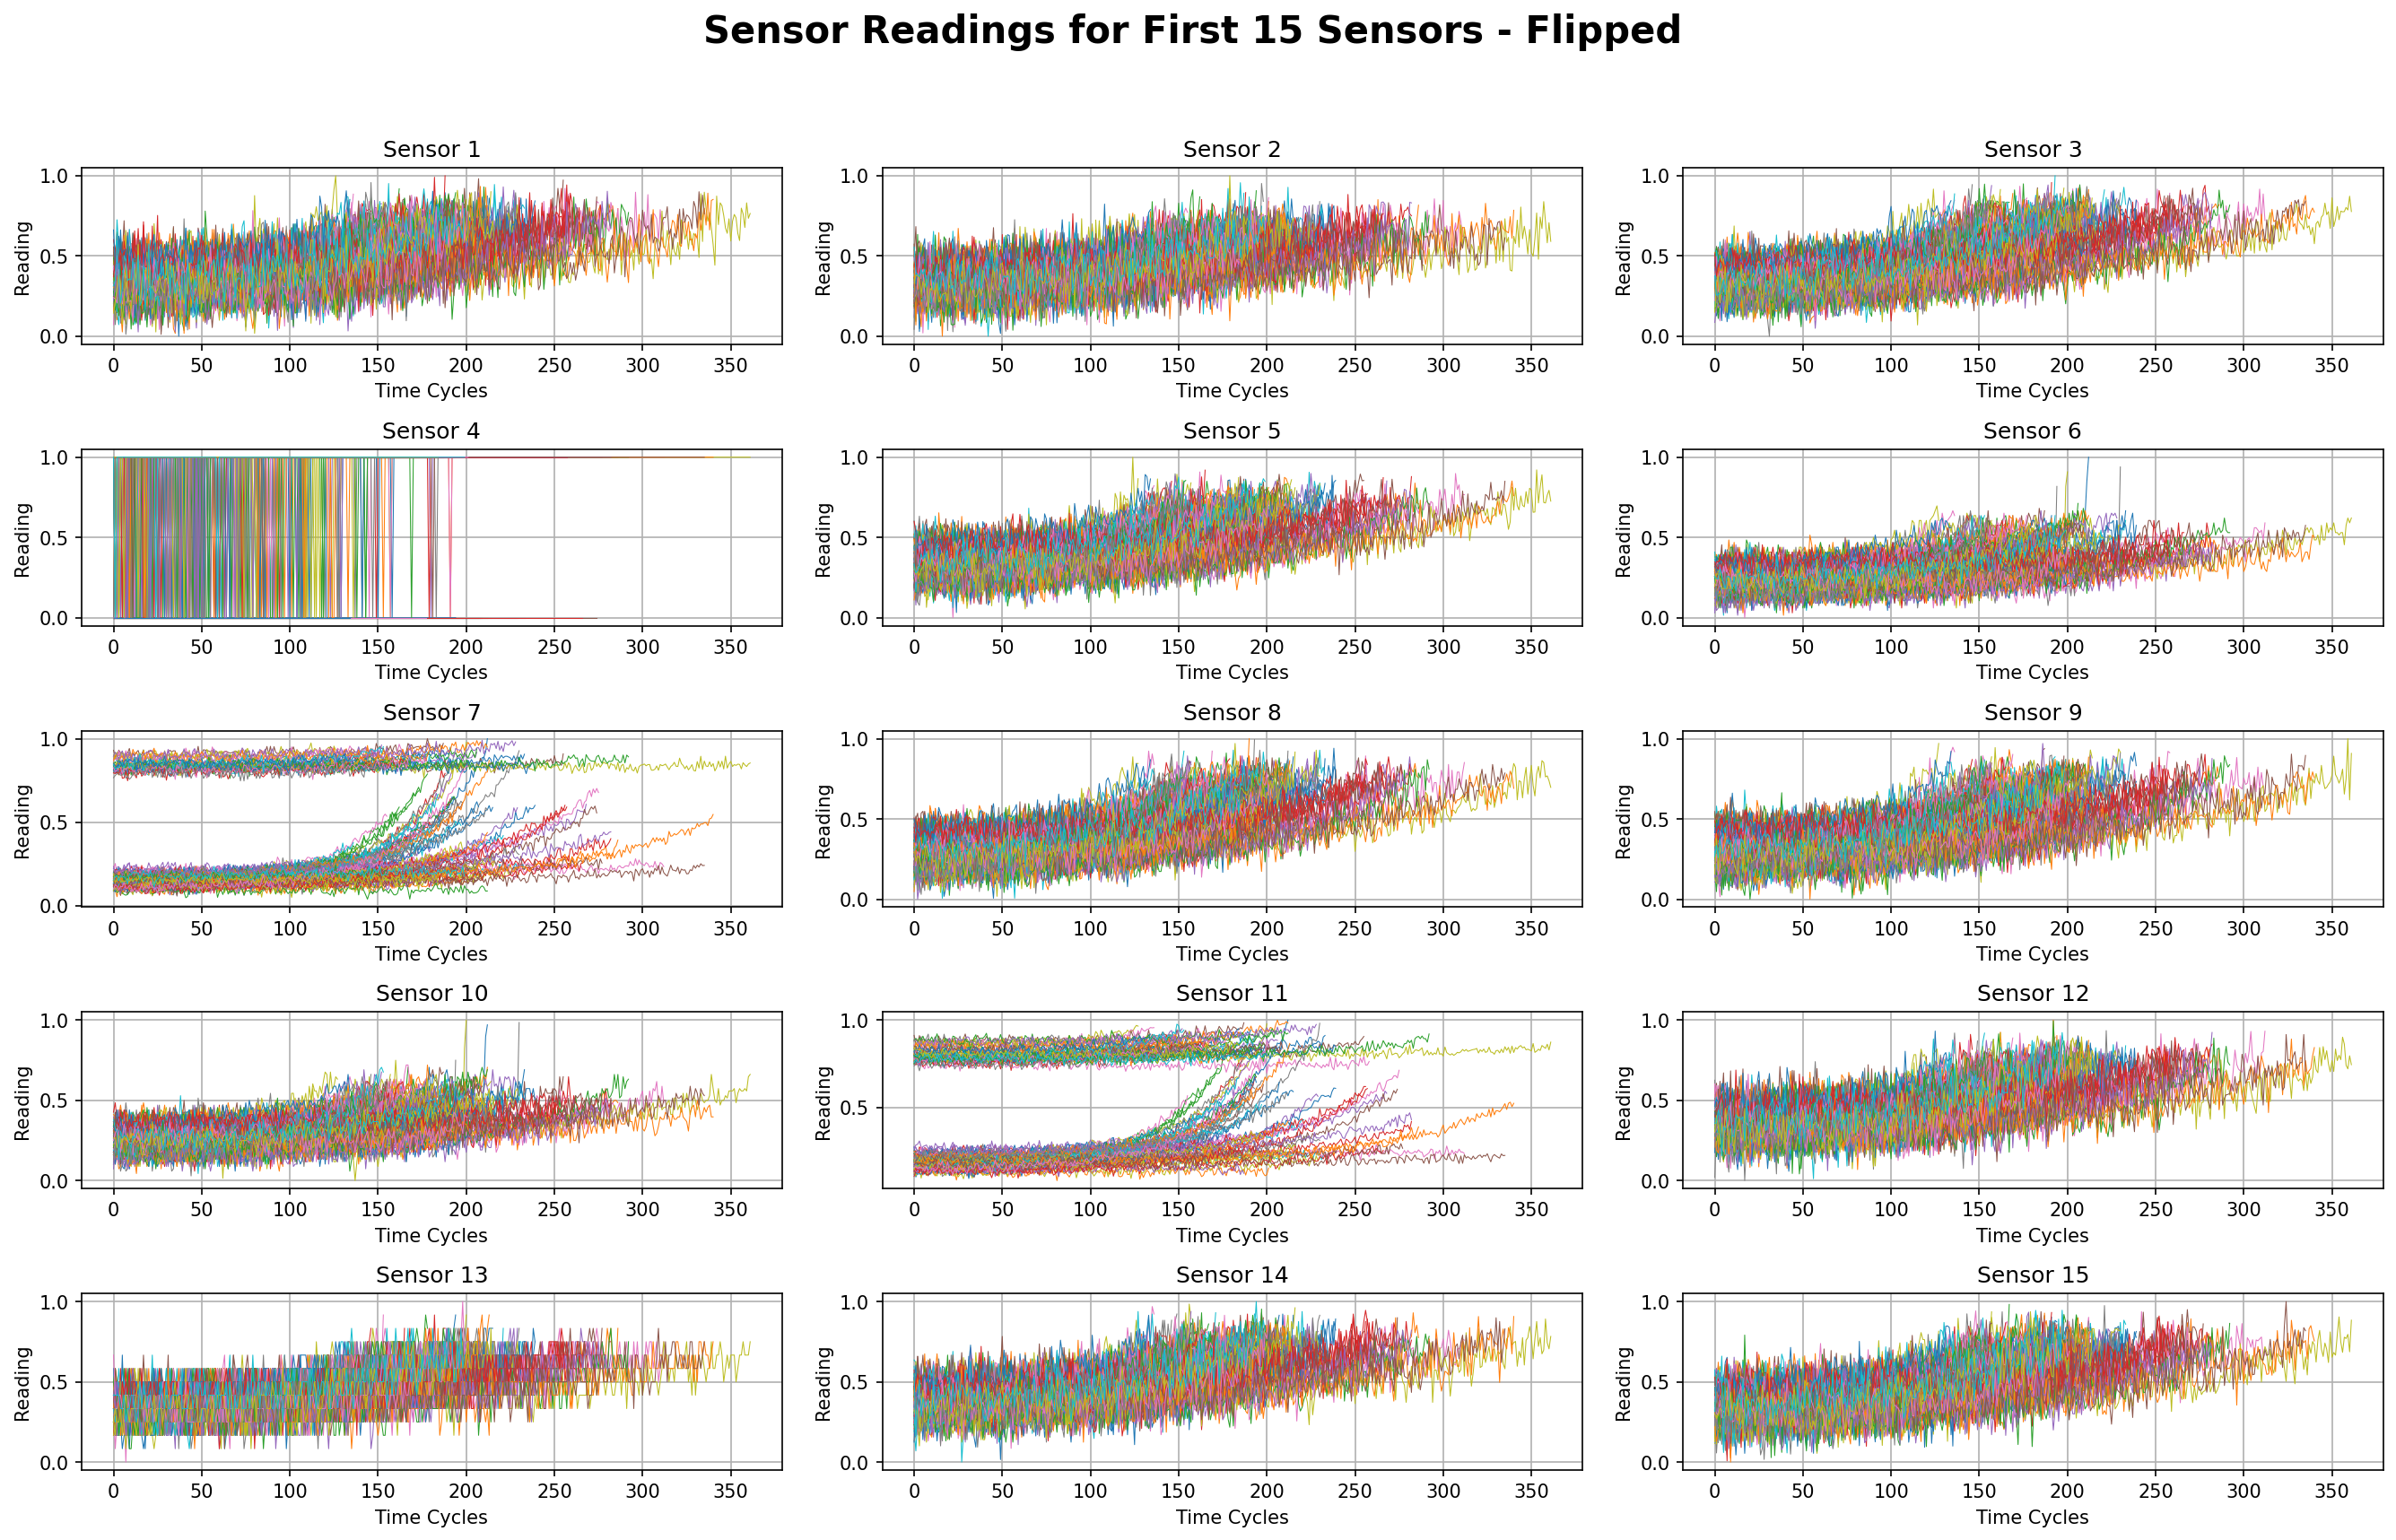

In [11]:
# Data_allup, flipped = all_up(Data)
fig, axs = plt.subplots(5, 3, figsize=(18, 12), dpi=150)
fig.suptitle('Sensor Readings for First 15 Sensors - Flipped', fontsize=20, fontweight='bold')

n_sensors_to_plot = 15
for idx in range(n_sensors_to_plot):
    ax = axs[idx // 3, idx % 3]
    for engine in Data_allup:
        signal = [flight[idx] for flight in engine]
        ax.plot(signal, linewidth=0.5)
    ax.set_title(f'Sensor {idx+1}')
    ax.set_xlabel('Time Cycles')
    ax.set_ylabel('Reading')
    ax.grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

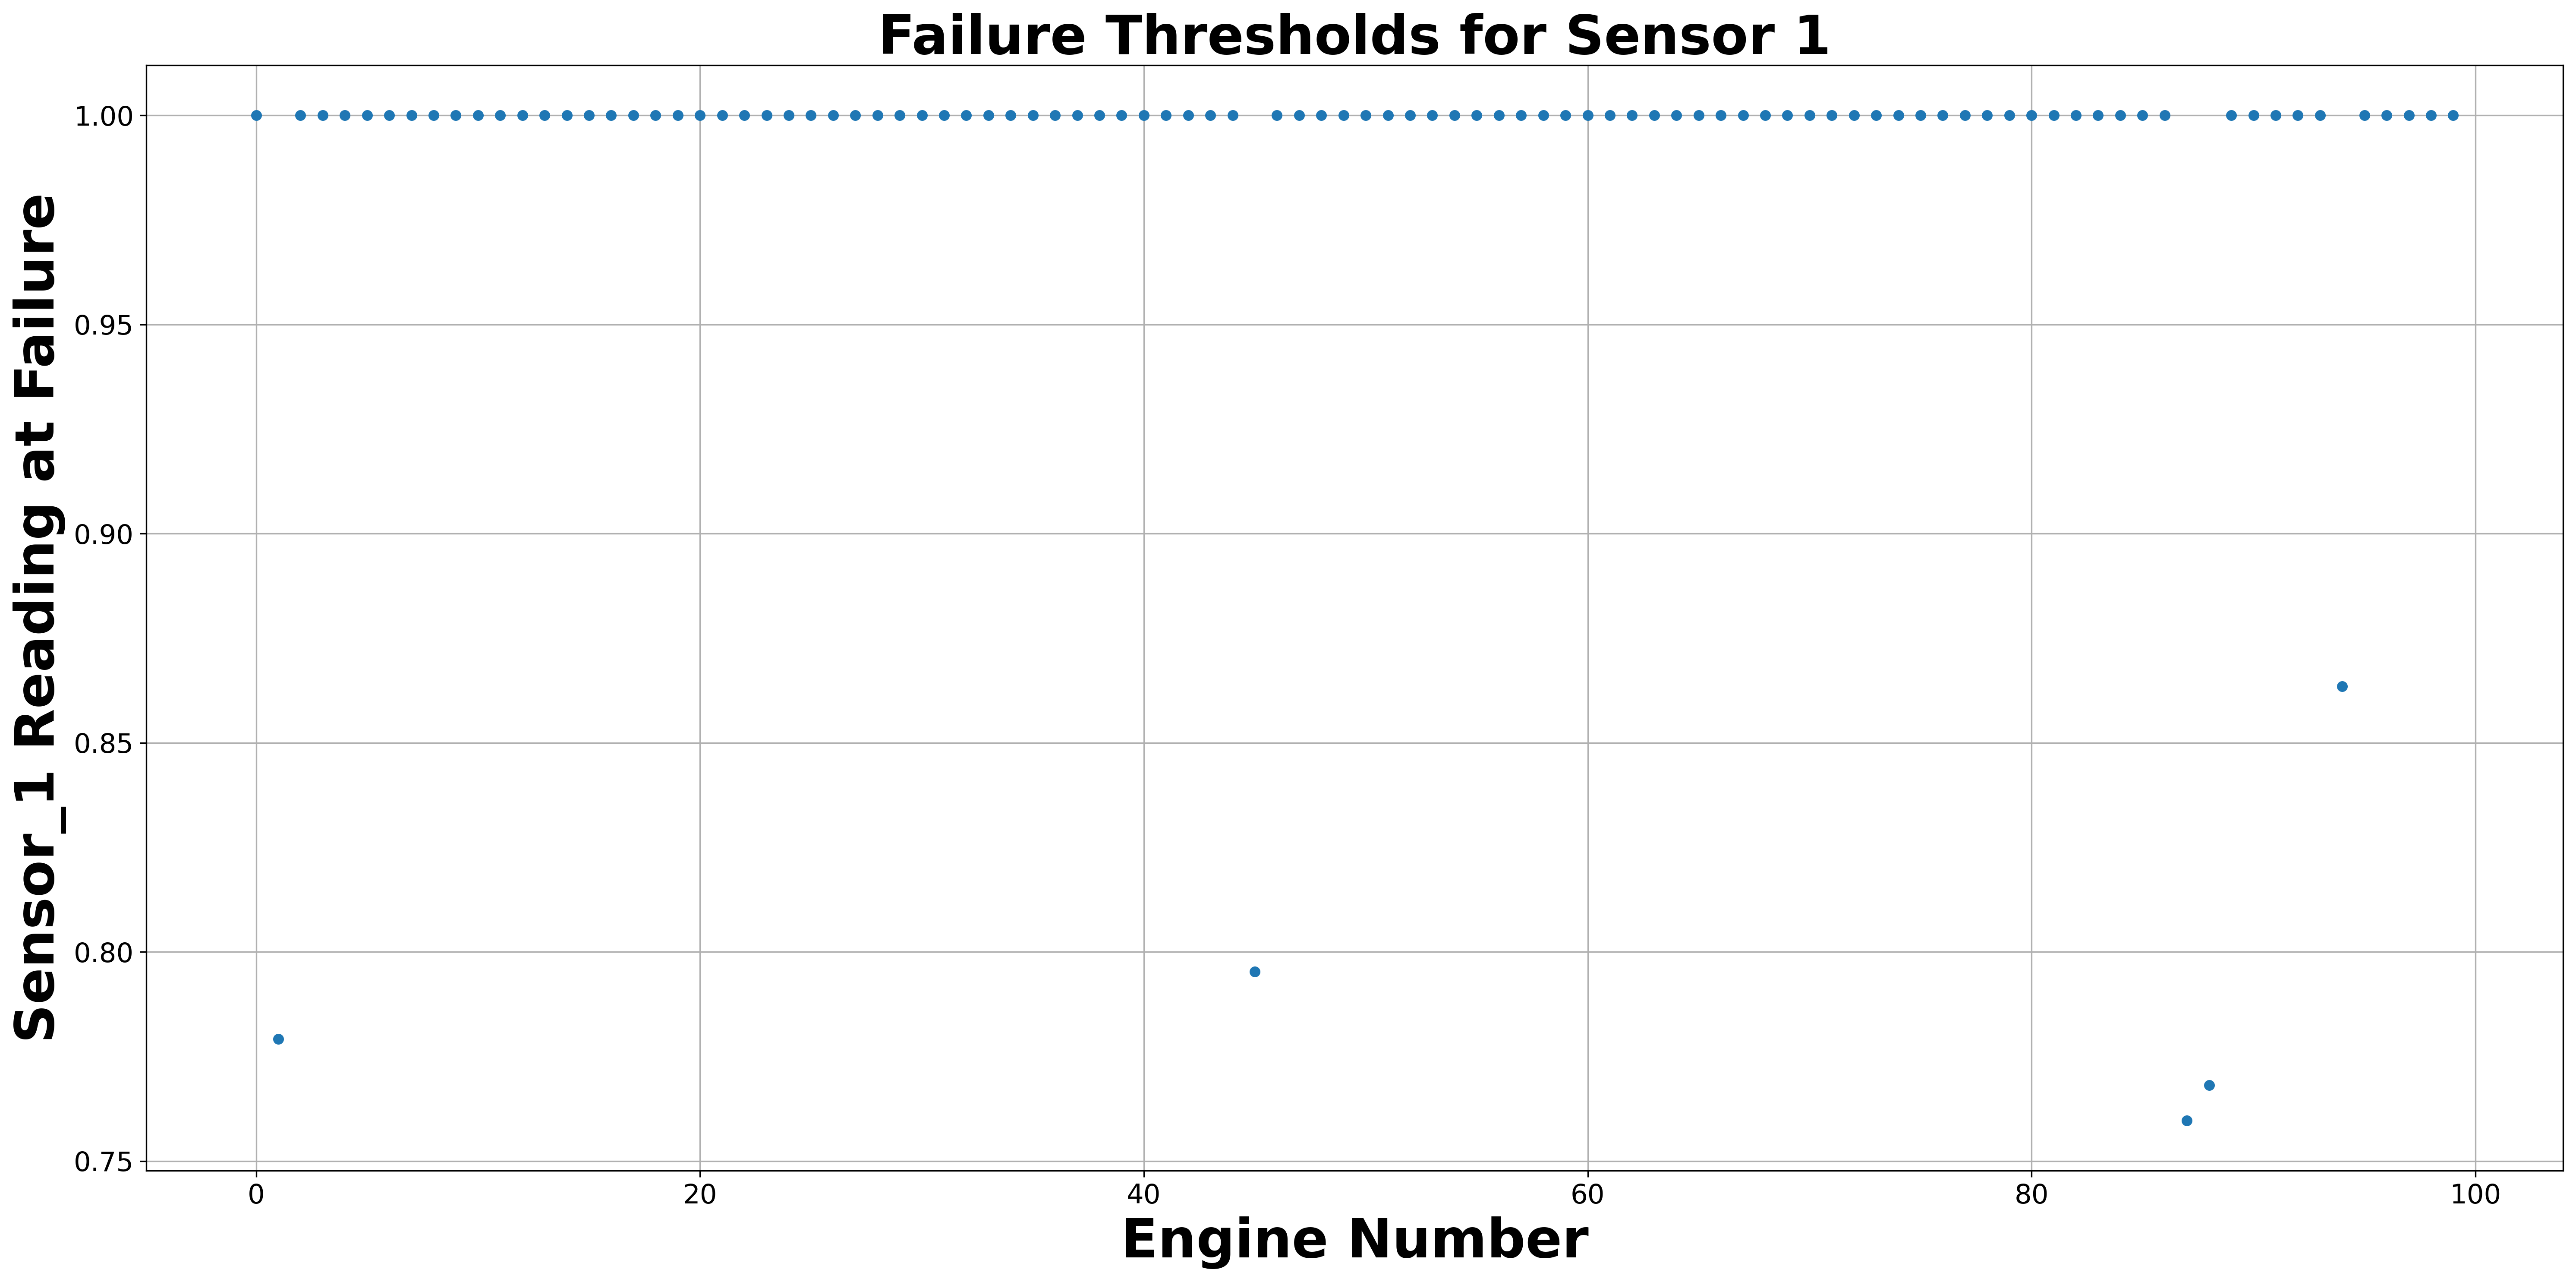

In [10]:
failure_thresholds = []
sensor = 0
for engine in Data:
    failure_thresholds.append(max(engine[:][sensor]))

plt.figure(figsize=(20,10), dpi=300)
plt.plot(failure_thresholds, marker='o', linestyle='', markersize=5)
plt.title(f"Failure Thresholds for Sensor {sensor+1}",fontweight='bold',size=30)
plt.xlabel('Engine Number',fontweight='bold',size=30)
plt.xticks(size=15)
plt.ylabel(f'Sensor_{sensor+1} Reading at Failure',fontweight='bold',size=30)
plt.yticks(size=15)
plt.grid(True)
plt.tight_layout()
# plt.savefig(f'Sensor_{sensor+1}_Failure_Thresholds.png')
plt.show()